# Notebook 01 — ERA5-Land 2024-2025: procesamiento climático

En este notebook trabajamos con datos ERA5-Land de 2024 y 2025 para construir el bloque climático del TFB.

El ámbito final de estudio es España peninsular, Portugal continental y Andorra. Los datos de ERA5-Land los descargamos sobre un área rectangular que contiene este ámbito y posteriormente los preparamos para el análisis territorial.

Trabajamos con variables instantáneas, como la temperatura, y variables acumuladas, como la precipitación o la radiación solar, porque requieren un tratamiento temporal diferente.

Los resultados describen las condiciones meteorológicas del periodo 2024-2025 y no una climatología histórica de largo plazo.


In [1]:
# Librerías y archivos climáticos
%pip install -q "cdsapi>=0.7.7" netCDF4 h5netcdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 46.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importamos librerias 
from pathlib import Path
import calendar
import time
import zipfile
import shutil
import cdsapi
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [3]:
# Configuración  
DATASET = "reanalysis-era5-land"

# Directorios
WORKING_DIR = Path("/kaggle/working")
INPUT_DIR = Path("/kaggle/input")

BASE_DIR = WORKING_DIR / "era5_land_2024_2025_v2"
RAW_DIR = BASE_DIR / "raw"
PROCESSED_DIR = BASE_DIR / "processed"
GRID_DIR = PROCESSED_DIR / "grid"
REGIONAL_DIR = PROCESSED_DIR / "regional"
FIGURES_DIR = BASE_DIR / "figures"
DASHBOARD_DIR = BASE_DIR / "dashboard"
SOURCES_DIR = BASE_DIR / "sources"
METADATA_DIR = BASE_DIR / "metadata"

carpetas_trabajo = [
    RAW_DIR,
    PROCESSED_DIR,
    GRID_DIR,
    REGIONAL_DIR,
    FIGURES_DIR,
    DASHBOARD_DIR,
    SOURCES_DIR,
    METADATA_DIR,
]

# Creamos los directorios
for carpeta in carpetas_trabajo:
    carpeta.mkdir(parents=True, exist_ok=True)

# Norte, Oeste, Sur, Este
AREA_IBERIA = [44, -10, 35, 4]  
YEARS = ["2024", "2025"]
MONTHS = [
    "01", "02", "03", "04", "05", "06",
    "07", "08", "09", "10", "11", "12"
]

# Horas UTC 
TIMES_STATE_UTC = [
    f"{hora:02d}:00"
    for hora in range(24)
]

print("Dataset:", DATASET)
print("Área de descarga:", AREA_IBERIA)
print("Años:", YEARS)
print("Meses:", len(MONTHS))
print("Horas diarias:", len(TIMES_STATE_UTC))


Dataset: reanalysis-era5-land
Área de descarga: [44, -10, 35, 4]
Años: ['2024', '2025']
Meses: 12
Horas diarias: 24


In [4]:
# Nombres para los 24 archivos mensuales
nombres_temperatura = []

for year in YEARS:
    for month in MONTHS:
        nombre = f"temperatura_2m_{year}_{month}.nc"
        nombres_temperatura.append(nombre)

total_esperado = len(nombres_temperatura)

# Archivos en la carpeta RAW.
archivos_temperatura = []

for nombre in nombres_temperatura:
    ruta = RAW_DIR / nombre

    if ruta.exists() and ruta.stat().st_size > 0:
        archivos_temperatura.append(ruta)

# Si faltan archivos, buscamos copia dentro de Kaggle
TEMPERATURA_INPUT_DIR = Path(
    "/kaggle/input/datasets/aemjeloy/1-ntb-era5-land-fin/"
    "era5_land_2024_2025_v2/raw"
)

if len(archivos_temperatura) != total_esperado:

    for nombre in nombres_temperatura:

        ruta_destino = RAW_DIR / nombre
        ruta_origen = TEMPERATURA_INPUT_DIR / nombre

        if not ruta_destino.exists() and ruta_origen.exists():

            shutil.copy2(
                ruta_origen,
                ruta_destino
            )

# Archivos disponibles.
archivos_temperatura = []

for nombre in nombres_temperatura:

    ruta = RAW_DIR / nombre

    if ruta.exists() and ruta.stat().st_size > 0:
        archivos_temperatura.append(ruta)

TEMPERATURA_DISPONIBLE = (
    len(archivos_temperatura)
    == total_esperado
)

DESCARGAR_TEMPERATURA = (
    not TEMPERATURA_DISPONIBLE
)

print("=== TEMPERATURA ===")
print(
    "Archivos disponibles:",
    len(archivos_temperatura),
    "de",
    total_esperado
)
print(
    "Temperatura disponible:",
    TEMPERATURA_DISPONIBLE
)
print(
    "Descarga necesaria:",
    DESCARGAR_TEMPERATURA
)

=== TEMPERATURA ===
Archivos disponibles: 24 de 24
Temperatura disponible: True
Descarga necesaria: False


In [5]:
# Variables de estado
VARIABLES_ESTADO = {
    "temperatura_2m": {
        "cds_name": "2m_temperature",
        "xarray_name_expected": "t2m",
        "file_template": "temperatura_2m_{year}_{month}.nc",
        "unidad_original": "K",
        "unidad_final": "°C",
        "conversion": "kelvin_a_celsius",
        "descripcion": "Temperatura del aire a 2 metros",
    },
    "punto_rocio_2m": {
        "cds_name": "2m_dewpoint_temperature",
        "xarray_name_expected": "d2m",
        "file_template": "punto_rocio_2m_{year}_{month}.nc",
        "unidad_original": "K",
        "unidad_final": "°C",
        "conversion": "kelvin_a_celsius",
        "descripcion": "Temperatura del punto de rocío a 2 metros",
    },
    "viento_u_10m": {
        "cds_name": "10m_u_component_of_wind",
        "xarray_name_expected": "u10",
        "file_template": "viento_u_10m_{year}_{month}.nc",
        "unidad_original": "m/s",
        "unidad_final": "m/s",
        "conversion": None,
        "descripcion": "Componente U del viento a 10 metros",
    },
    "viento_v_10m": {
        "cds_name": "10m_v_component_of_wind",
        "xarray_name_expected": "v10",
        "file_template": "viento_v_10m_{year}_{month}.nc",
        "unidad_original": "m/s",
        "unidad_final": "m/s",
        "conversion": None,
        "descripcion": "Componente V del viento a 10 metros",
    },
    "humedad_suelo_superficial": {
        "cds_name": "volumetric_soil_water_layer_1",
        "xarray_name_expected": "swvl1",
        "file_template": "humedad_suelo_superficial_{year}_{month}.nc",
        "unidad_original": "m³/m³",
        "unidad_final": "m³/m³",
        "conversion": None,
        "descripcion": "Humedad volumétrica del suelo superficial (0-7 cm)",
    },
}

# Variables acumuladas
VARIABLES_ACUMULADAS = {
    "precipitacion_total": {
        "cds_name": "total_precipitation",
        "xarray_name_expected": "tp",
        "file_template": "precipitacion_total_{year}_{month}.nc",
        "unidad_original": "m",
        "unidad_final": "mm",
        "conversion": "metros_a_milimetros",
        "descripcion": "Precipitación total",
    },
    "radiacion_solar": {
        "cds_name": "surface_solar_radiation_downwards",
        "xarray_name_expected": "ssrd",
        "file_template": "radiacion_solar_{year}_{month}.nc",
        "unidad_original": "J/m²",
        "unidad_final": "MJ/m²",
        "conversion": "julios_a_megajulios",
        "descripcion": "Radiación solar descendente en superficie",
    },
}

# Variables derivadas
VARIABLES_DERIVADAS = {
    "velocidad_viento_10m": {
        "variables_origen": ["viento_u_10m", "viento_v_10m"],
        "formula": "sqrt(u10**2 + v10**2)",
        "unidad_final": "m/s",
    }
}

# Resumen
total_variables = (
    len(VARIABLES_ESTADO)
    + len(VARIABLES_ACUMULADAS)
    + len(VARIABLES_DERIVADAS)
)
print("=== VARIABLES ERA5-LAND ===")
print("Variables de estado:", len(VARIABLES_ESTADO))
print("Variables acumuladas:", len(VARIABLES_ACUMULADAS))
print("Variables derivadas:", len(VARIABLES_DERIVADAS))
print("Total definido:", total_variables)


=== VARIABLES ERA5-LAND ===
Variables de estado: 5
Variables acumuladas: 2
Variables derivadas: 1
Total definido: 8


In [6]:
# Descargar datos
def obtener_dias_mes(year, month):
    numero_dias = calendar.monthrange(int(year), int(month))[1]
    dias = []
    for dia in range(1, numero_dias + 1):
        dias.append(f"{dia:02d}")
    return dias

def validar_archivo_netcdf(ruta, variable, registros_esperados):
    """Archivo con los datos OK."""
    if not ruta.exists() or ruta.stat().st_size == 0:
        return False
    try:
        with xr.open_dataset(ruta) as dataset:
            if variable not in dataset.data_vars:
                return False
            if "valid_time" in dataset.sizes:
                dimension_tiempo = "valid_time"
            elif "time" in dataset.sizes:
                dimension_tiempo = "time"
            else:
                return False
            if dataset.sizes[dimension_tiempo] != registros_esperados:
                return False
        return True
    except Exception:
        return False

def descargar_variable_mensual(
    variable_key,
    tipo_variable,
    year,
    month,
    max_reintentos=3
):
    """Descargamos y comprobamos un archivo mensual"""
    dias = obtener_dias_mes(year, month)

    # Configuración según el tipo de variable.
    if tipo_variable == "estado":
        config = VARIABLES_ESTADO[variable_key]
        horas = TIMES_STATE_UTC
        registros_esperados = len(dias) * 24
    elif tipo_variable == "acumulada":
        config = VARIABLES_ACUMULADAS[variable_key]
        horas = ["00:00"]
        registros_esperados = len(dias)
    else:
        raise ValueError(
            'tipo_variable debe ser "estado" o "acumulada".'
        )
    request = {
        "variable": [config["cds_name"]],
        "year": [year],
        "month": [month],
        "day": dias,
        "time": horas,
        "data_format": "netcdf",
        "download_format": "unarchived",
        "area": AREA_IBERIA,
    }
    nombre_archivo = config["file_template"].format(
        year=year,
        month=month
    )
    ruta_final = RAW_DIR / nombre_archivo
    ruta_temporal = RAW_DIR / f"{nombre_archivo}.part"

    # Si el archivo esta correcto, lo reutilizamos.
    if validar_archivo_netcdf(
        ruta_final,
        config["xarray_name_expected"],
        registros_esperados
    ):
        print("Archivo disponible:", nombre_archivo)
        return ruta_final

    # Si tenemos que descargar, hasta tres intentos.
    for intento in range(1, max_reintentos + 1):
        try:
            print(
                f"Descargando {variable_key} "
                f"{year}-{month} ({intento}/{max_reintentos})"
            )
            client = cdsapi.Client()
            client.retrieve(
                DATASET,
                request,
                str(ruta_temporal)
            )
            archivo_valido = validar_archivo_netcdf(
                ruta_temporal,
                config["xarray_name_expected"],
                registros_esperados
            )
            if not archivo_valido:
                raise RuntimeError(
                    "Descarga NOK"
                )
            ruta_temporal.replace(ruta_final)
            print("Archivo validado:", nombre_archivo)
            return ruta_final

        except Exception as error:
            if ruta_temporal.exists():
                ruta_temporal.unlink()
            if intento == max_reintentos:
                raise
            espera = 30 * intento
            print("Error:", error)
            print(f"Reintentamos en {espera} segundos.")
            time.sleep(espera)



In [7]:
# Configuracio de CDS
import os

CDS_CONFIG_PATH = Path.home() / ".cdsapirc"
CDS_URL = "https://cds.climate.copernicus.eu/api"

# Si existe, la reutilizamos.
if CDS_CONFIG_PATH.exists():
    print("Configuración de Copernicus disponible.")
else:
    CDS_API_KEY = os.getenv("CDS_API_KEY")
    origen_token = "variable de entorno"

    # Buscamos el token en Secrets de Kaggle
    if CDS_API_KEY is None:
        try:
            from kaggle_secrets import UserSecretsClient
            user_secrets = UserSecretsClient()
            CDS_API_KEY = user_secrets.get_secret("CDS_API_KEY")
            origen_token = "Kaggle Secrets"
        except Exception:
            CDS_API_KEY = None

    if CDS_API_KEY is None or str(CDS_API_KEY).strip() == "":
        raise RuntimeError(
            "No se ha encontrado CDS_API_KEY. "
            "Añádelo a Kaggle Secrets"
        )

    # Creamos el archivo que usa cdsapi.
    with open(CDS_CONFIG_PATH, "w", encoding="utf-8") as archivo:
        archivo.write(f"url: {CDS_URL}\n")
        archivo.write(f"key: {str(CDS_API_KEY).strip()}\n")
    print("Configuración creada.")
    print("Credencial obtenida:", origen_token)


Configuración creada.
Credencial obtenida: Kaggle Secrets


In [8]:
# Configuracion CDS, comprobacion
if not CDS_CONFIG_PATH.exists():
    raise FileNotFoundError(
        "No se ha encontrado el archivo .cdsapirc."
    )
lineas = CDS_CONFIG_PATH.read_text(
    encoding="utf-8"
).splitlines()

url_correcta = False
token_presente = False

for linea in lineas:
    if linea.startswith("url: "):
        url_correcta = True
    if linea.startswith("key: "):
        token = linea.split(":", 1)[1].strip()
        if token != "":
            token_presente = True

if not url_correcta:
    raise ValueError(
        "No se ha encontrado la URL de Copernicus."
    )
if not token_presente:
    raise ValueError(
        "No se ha encontrado una clave válida de Copernicus."
    )


In [9]:
# Recuperar trabajo
import shutil
carpetas_guardadas = list(
    INPUT_DIR.rglob("era5_land_2024_2025_v2")
)
if len(carpetas_guardadas) > 0:
    shutil.copytree(
        carpetas_guardadas[0],
        BASE_DIR,
        dirs_exist_ok=True
    )
    print("Trabajo anterior recuperado")
else:
    print(
        "No hay copia anterior"
    )

Trabajo anterior recuperado


In [10]:
# Trabajo recuperado
archivos_temperatura = list(
    RAW_DIR.glob("temperatura_2m_*.nc")
)
archivos_punto_rocio = list(
    RAW_DIR.glob("punto_rocio_2m_*.nc")
)
print(
    "Temperatura:",
    len(archivos_temperatura),
    "archivos de 24"
)
print(
    "Punto de rocío:",
    len(archivos_punto_rocio),
    "archivos de 24"
)
if (
    len(archivos_temperatura) == 24
    and len(archivos_punto_rocio) == 24
):
    print("\nTrabajo recuperado")
else:
    print(
        "\nLa recuperación es parcial. "
        "Recuperamos en las siguientes celdas los archivos que faltan."
    )

Temperatura: 24 archivos de 24
Punto de rocío: 24 archivos de 24

Trabajo recuperado


In [11]:
# descarga del periodo completo de una variable
def descargar_periodo_variable(
    variable_key,
    tipo_variable,
    max_reintentos=3
):
    
# descargamos todos los meses definidos en YEARS y MONTHS para una variable de ERA5-Land.
    rutas_descargadas = []
    registros_descarga = []

    total_meses = len(YEARS) * len(MONTHS)
    mes_actual = 0

    # Recorremos años y meses 
    for year in YEARS:
        for month in MONTHS:
            mes_actual += 1
            
            print(
                f"[{mes_actual}/{total_meses}] "
                f"{variable_key}: {year}-{month}"
            )
            
            ruta_archivo = descargar_variable_mensual(
                variable_key,
                tipo_variable,
                year,
                month,
                max_reintentos=max_reintentos,
            )

            tamano_mb = round(
                ruta_archivo.stat().st_size / 1_000_000,
                2,
            )

            rutas_descargadas.append(ruta_archivo)
            registros_descarga.append({
                "year": year,
                "month": month,
                "archivo": ruta_archivo.name,
                "tamano_mb": tamano_mb,
            })

    # Si se ha descargado
    if len(rutas_descargadas) != total_meses:
        raise RuntimeError(
            f"Se descargaron {len(rutas_descargadas)} archivos "
            f"de los {total_meses} esperados."
        )

    # Guardamos
    inventario = pd.DataFrame(registros_descarga)
    ruta_inventario = (
        METADATA_DIR
        / f"estado_descarga_{variable_key}.csv"
    )
    inventario.to_csv(
        ruta_inventario,
        index=False,
    )
    print()
    print(
        "Periodo completo:",
        len(rutas_descargadas),
        "de",
        total_meses,
        "archivos.",
    )
    print("Inventario guardado en:", ruta_inventario)

    return (
        rutas_descargadas,
        inventario,
        ruta_inventario,
    )

In [12]:
# Tewmperatura a 2m
rutas_temperatura, inventario_temperatura, ruta_inventario_temperatura = (
    descargar_periodo_variable(
        variable_key="temperatura_2m",
        tipo_variable="estado",
        max_reintentos=3
    )
)
TEMPERATURA_DISPONIBLE = len(rutas_temperatura) == 24
DESCARGAR_TEMPERATURA = not TEMPERATURA_DISPONIBLE

print("\nArchivos de temperatura:", len(rutas_temperatura), "de 24")
print("Temperatura disponible:", TEMPERATURA_DISPONIBLE)

[1/24] temperatura_2m: 2024-01
Archivo disponible: temperatura_2m_2024_01.nc
[2/24] temperatura_2m: 2024-02
Archivo disponible: temperatura_2m_2024_02.nc
[3/24] temperatura_2m: 2024-03
Archivo disponible: temperatura_2m_2024_03.nc
[4/24] temperatura_2m: 2024-04
Archivo disponible: temperatura_2m_2024_04.nc
[5/24] temperatura_2m: 2024-05
Archivo disponible: temperatura_2m_2024_05.nc
[6/24] temperatura_2m: 2024-06
Archivo disponible: temperatura_2m_2024_06.nc
[7/24] temperatura_2m: 2024-07
Archivo disponible: temperatura_2m_2024_07.nc
[8/24] temperatura_2m: 2024-08
Archivo disponible: temperatura_2m_2024_08.nc
[9/24] temperatura_2m: 2024-09
Archivo disponible: temperatura_2m_2024_09.nc
[10/24] temperatura_2m: 2024-10
Archivo disponible: temperatura_2m_2024_10.nc
[11/24] temperatura_2m: 2024-11
Archivo disponible: temperatura_2m_2024_11.nc
[12/24] temperatura_2m: 2024-12
Archivo disponible: temperatura_2m_2024_12.nc
[13/24] temperatura_2m: 2025-01
Archivo disponible: temperatura_2m_2025_0

In [13]:
# Conversion a celsius y resumen mensual 
config_temperatura = VARIABLES_ESTADO["temperatura_2m"]
variable_netcdf = config_temperatura["xarray_name_expected"]
plantilla_archivo = config_temperatura["file_template"]

total_archivos = len(YEARS) * len(MONTHS)
horas_por_dia = len(TIMES_STATE_UTC)
periodo = f"{YEARS[0]}-{YEARS[-1]}"
periodo_archivo = f"{YEARS[0]}_{YEARS[-1]}"

resumen_mensual = []
suma_global = 0.0
valores_global = 0
registros_temporales = 0
archivo_actual = 0

for year in YEARS:
    for month in MONTHS:
        archivo_actual += 1
        nombre_archivo = plantilla_archivo.format(
            year=year,
            month=month,
        )
        ruta_archivo = RAW_DIR / nombre_archivo
        dias_mes = len(obtener_dias_mes(year, month))
        registros_esperados = dias_mes * horas_por_dia

        with xr.open_dataset(ruta_archivo) as ds:
            temperatura_c = (
                ds[variable_netcdf].squeeze(drop=True) - 273.15
            )
            if "valid_time" in temperatura_c.dims:
                dimension_tiempo = "valid_time"
            elif "time" in temperatura_c.dims:
                dimension_tiempo = "time"
            else:
                raise ValueError(
                    f"Sin dimensión temporal: {nombre_archivo}"
                )
            registros_mes = temperatura_c.sizes[dimension_tiempo]
            valores_mes = int(temperatura_c.count().values)

            if registros_mes != registros_esperados:
                raise RuntimeError(
                    f"Registros incorrectos en {nombre_archivo}: "
                    f"{registros_mes} obtenidos y "
                    f"{registros_esperados} esperados."
                )
            if valores_mes == 0:
                raise RuntimeError(
                    f"Sin valores válidos en {nombre_archivo}."
                )

            suma_mes = float(
                temperatura_c.sum(skipna=True).values
            )

            resumen_mensual.append({
                "year": year,
                "month": month,
                "registros_temporales": registros_mes,
                "valores_validos": valores_mes,
                "temperatura_minima_c": float(
                    temperatura_c.min(skipna=True).values
                ),
                "temperatura_maxima_c": float(
                    temperatura_c.max(skipna=True).values
                ),
                "temperatura_media_c": suma_mes / valores_mes,
            })

        registros_temporales += registros_mes
        valores_global += valores_mes
        suma_global += suma_mes

        print(
            f"[{archivo_actual}/{total_archivos}] "
            f"{nombre_archivo}"
        )

# Resumen
resumen_temperatura = pd.DataFrame(resumen_mensual)
temperatura_min_global = (
    resumen_temperatura["temperatura_minima_c"].min()
)
temperatura_max_global = (
    resumen_temperatura["temperatura_maxima_c"].max()
)
temperatura_media_global = suma_global / valores_global
ruta_resumen_temperatura = (
    METADATA_DIR
    / f"resumen_temperatura_celsius_{periodo_archivo}.csv"
)
resumen_temperatura.to_csv(
    ruta_resumen_temperatura,
    index=False,
)

print(
    f"\n=== RESUMEN TEMPERATURA {periodo} ===\n"
    f"Archivos procesados: {len(resumen_temperatura)}/{total_archivos}\n"
    f"Registros horarios: {registros_temporales}\n"
    f"Valores válidos: {valores_global}\n"
    f"Temperatura mínima: {temperatura_min_global:.4f} °C\n"
    f"Temperatura máxima: {temperatura_max_global:.4f} °C\n"
    f"Temperatura media: {temperatura_media_global:.4f} °C\n"
    f"Resumen guardado en: {ruta_resumen_temperatura}"
)

[1/24] temperatura_2m_2024_01.nc
[2/24] temperatura_2m_2024_02.nc
[3/24] temperatura_2m_2024_03.nc
[4/24] temperatura_2m_2024_04.nc
[5/24] temperatura_2m_2024_05.nc
[6/24] temperatura_2m_2024_06.nc
[7/24] temperatura_2m_2024_07.nc
[8/24] temperatura_2m_2024_08.nc
[9/24] temperatura_2m_2024_09.nc
[10/24] temperatura_2m_2024_10.nc
[11/24] temperatura_2m_2024_11.nc
[12/24] temperatura_2m_2024_12.nc
[13/24] temperatura_2m_2025_01.nc
[14/24] temperatura_2m_2025_02.nc
[15/24] temperatura_2m_2025_03.nc
[16/24] temperatura_2m_2025_04.nc
[17/24] temperatura_2m_2025_05.nc
[18/24] temperatura_2m_2025_06.nc
[19/24] temperatura_2m_2025_07.nc
[20/24] temperatura_2m_2025_08.nc
[21/24] temperatura_2m_2025_09.nc
[22/24] temperatura_2m_2025_10.nc
[23/24] temperatura_2m_2025_11.nc
[24/24] temperatura_2m_2025_12.nc

=== RESUMEN TEMPERATURA 2024-2025 ===
Archivos procesados: 24/24
Registros horarios: 17544
Valores válidos: 137387064
Temperatura mínima: -16.2215 °C
Temperatura máxima: 45.9081 °C
Temperatura

In [14]:
# Temperatura media 2024-2025
DERIVED_DIR = PROCESSED_DIR / "derived"
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

ruta_temperatura_media_espacial = (
    DERIVED_DIR
    / "temperatura_media_espacial_2024_2025.nc"
)

suma_temperatura = None
conteo_temperatura = None
registros_totales = 0

for year in YEARS:
    for month in MONTHS:
        nombre_archivo = f"temperatura_2m_{year}_{month}.nc"
        ruta_archivo = RAW_DIR / nombre_archivo

        with xr.open_dataset(ruta_archivo) as ds:
            if "valid_time" in ds.sizes:
                dimension_tiempo = "valid_time"
            else:
                dimension_tiempo = "time"

            # Convertimos a Celsius.
            temperatura_c = ds["t2m"] - 273.15
            suma_mes = temperatura_c.sum(
                dim=dimension_tiempo,
                skipna=True
            ).load()
            
            conteo_mes = temperatura_c.count(
                dim=dimension_tiempo
            ).load()

            if suma_temperatura is None:
                suma_temperatura = suma_mes
                conteo_temperatura = conteo_mes
            else:
                suma_temperatura += suma_mes
                conteo_temperatura += conteo_mes
            registros_totales += ds.sizes[dimension_tiempo]
        print("Procesado:", nombre_archivo)

if registros_totales != 17544:
    raise RuntimeError(
        "Numero de registros horarios NOK"
    )

# Media temporal para cada celda de la malla.
temperatura_media_espacial = (
    suma_temperatura
    / conteo_temperatura.where(conteo_temperatura > 0)
)
temperatura_media_espacial.name = "temperatura_media_2m_c"
temperatura_media_espacial.attrs["units"] = "°C"
temperatura_media_espacial.attrs["source"] = "ERA5-Land"
temperatura_media_espacial.attrs["periodo"] = "2024-2025"

# Guardamos la capa
temperatura_media_espacial.to_netcdf(
    ruta_temperatura_media_espacial
)
celdas_validas = int(
    np.isfinite(temperatura_media_espacial.values).sum()
)
temperatura_minima = float(
    temperatura_media_espacial.min(skipna=True).values
)
temperatura_maxima = float(
    temperatura_media_espacial.max(skipna=True).values
)

print("\n=== TEMPERATURA MEDIA ESPACIAL ===")
print("Registros horarios:", registros_totales)
print("Dimensiones:", dict(temperatura_media_espacial.sizes))
print("Celdas válidas:", celdas_validas)
print("Temperatura media mínima:", round(temperatura_minima, 4), "°C")
print("Temperatura media máxima:", round(temperatura_maxima, 4), "°C")
print("Archivo guardado:", ruta_temperatura_media_espacial)

Procesado: temperatura_2m_2024_01.nc
Procesado: temperatura_2m_2024_02.nc
Procesado: temperatura_2m_2024_03.nc
Procesado: temperatura_2m_2024_04.nc
Procesado: temperatura_2m_2024_05.nc
Procesado: temperatura_2m_2024_06.nc
Procesado: temperatura_2m_2024_07.nc
Procesado: temperatura_2m_2024_08.nc
Procesado: temperatura_2m_2024_09.nc
Procesado: temperatura_2m_2024_10.nc
Procesado: temperatura_2m_2024_11.nc
Procesado: temperatura_2m_2024_12.nc
Procesado: temperatura_2m_2025_01.nc
Procesado: temperatura_2m_2025_02.nc
Procesado: temperatura_2m_2025_03.nc
Procesado: temperatura_2m_2025_04.nc
Procesado: temperatura_2m_2025_05.nc
Procesado: temperatura_2m_2025_06.nc
Procesado: temperatura_2m_2025_07.nc
Procesado: temperatura_2m_2025_08.nc
Procesado: temperatura_2m_2025_09.nc
Procesado: temperatura_2m_2025_10.nc
Procesado: temperatura_2m_2025_11.nc
Procesado: temperatura_2m_2025_12.nc

=== TEMPERATURA MEDIA ESPACIAL ===
Registros horarios: 17544
Dimensiones: {'latitude': 91, 'longitude': 141}
Ce

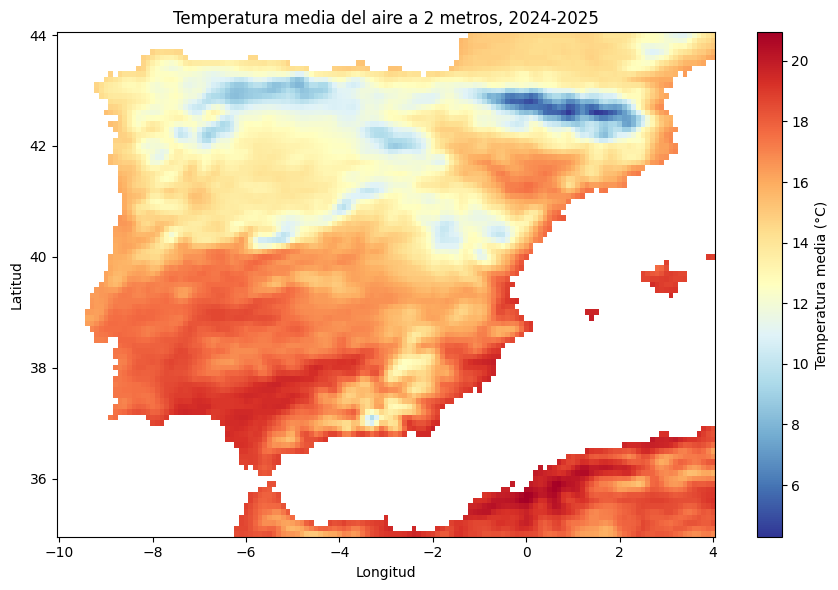

=== MAPA DE TEMPERATURA MEDIA ===
Celdas: 7831
Temperatura media mínima: 4.2966 °C
Temperatura media máxima: 20.9397 °C


In [15]:
# Mapa de temperatura media 2024-2025
ruta_figura_temperatura_media = (
    FIGURES_DIR
    / "mapa_temperatura_media_2024_2025.png"
)

# Comprobamos que existe la capa calculada
if not ruta_temperatura_media_espacial.exists():
    raise FileNotFoundError(
        "No se encuentra la capa"
    )

# Cargamos la temperatura media
with xr.open_dataset(ruta_temperatura_media_espacial) as ds:
    temperatura_mapa = ds["temperatura_media_2m_c"].load()
temperatura_minima_mapa = float(
    temperatura_mapa.min(skipna=True).values
)
temperatura_maxima_mapa = float(
    temperatura_mapa.max(skipna=True).values
)
celdas_validas = int(
    temperatura_mapa.count().values
)

# Representamos la capa
fig, ax = plt.subplots(figsize=(9, 6))
temperatura_mapa.plot(
    ax=ax,
    cmap="RdYlBu_r",
    cbar_kwargs={
        "label": "Temperatura media (°C)"
    }
)
ax.set_title(
    "Temperatura media del aire a 2 metros, 2024-2025"
)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.tight_layout()

fig.savefig(
    ruta_figura_temperatura_media,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("=== MAPA DE TEMPERATURA MEDIA ===")
print("Celdas:", celdas_validas)
print(
    "Temperatura media mínima:",
    round(temperatura_minima_mapa, 4),
    "°C"
)
print(
    "Temperatura media máxima:",
    round(temperatura_maxima_mapa, 4),
    "°C"
)


In [16]:
# temperatura mensual en tres puntos de referencia
puntos_referencia = {
    "Madrid": (40.42, -3.70),
    "Lisboa": (38.72, -9.14),
    "Andorra la Vella": (42.51, 1.52),
}

datos_puntos = []
for year in YEARS:
    for month in MONTHS:
        nombre_archivo = plantilla_archivo.format(
            year=year,
            month=month,
        )
        ruta_archivo = RAW_DIR / nombre_archivo

        with xr.open_dataset(ruta_archivo) as ds:
            temperatura_c = (
                ds[variable_netcdf].squeeze(drop=True)
                - 273.15
            )
            tiempo = (
                "valid_time"
                if "valid_time" in temperatura_c.dims
                else "time"
            )

            for lugar, (latitud, longitud) in puntos_referencia.items():
                punto = temperatura_c.sel(
                    latitude=latitud,
                    longitude=longitud,
                    method="nearest",
                )
                datos_puntos.append({
                    "lugar": lugar,
                    "year": year,
                    "month": month,
                    "temperatura_media_c": float(
                        punto.mean(
                            dim=tiempo,
                            skipna=True,
                        ).values
                    ),
                    "latitud_rejilla": float(
                        punto["latitude"].values
                    ),
                    "longitud_rejilla": float(
                        punto["longitude"].values
                    ),
                })

temperatura_puntos = pd.DataFrame(datos_puntos)
temperatura_puntos["fecha"] = pd.to_datetime({
    "year": temperatura_puntos["year"],
    "month": temperatura_puntos["month"],
    "day": 1,
})

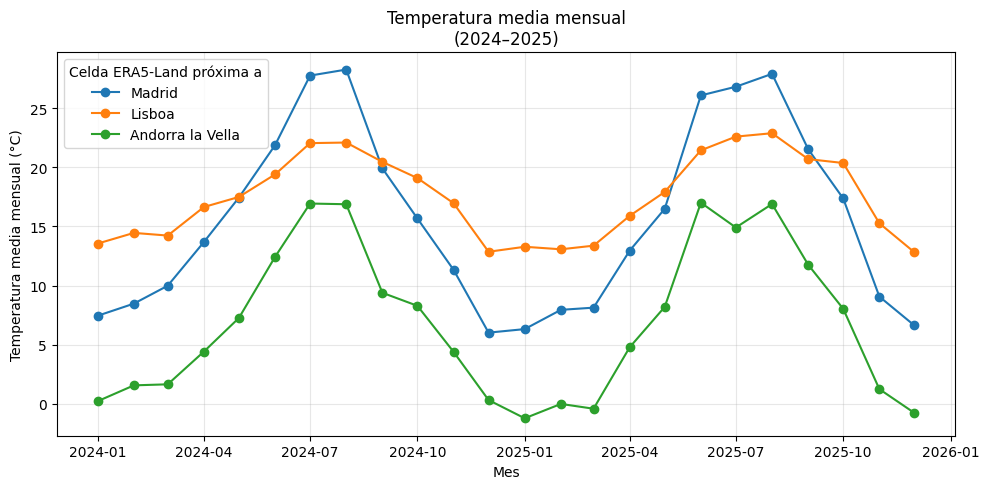

In [17]:
# Comparación temporal de esos tres puntos de referencia
ruta_grafico_puntos = (
    FIGURES_DIR
    / "temperatura_puntos_referencia_2024_2025.png"
)

plt.figure(figsize=(10, 5))

for lugar, datos in temperatura_puntos.groupby(
    "lugar",
    sort=False,
):
    plt.plot(
        datos["fecha"],
        datos["temperatura_media_c"],
        marker="o",
        label=lugar,
    )

plt.title(
    "Temperatura media mensual\n"
    "(2024–2025)"
)
plt.xlabel("Mes")
plt.ylabel("Temperatura media mensual (°C)")
plt.legend(title="Celda ERA5-Land próxima a")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    ruta_grafico_puntos,
    dpi=300,
    bbox_inches="tight",
)
plt.show()



### Temperatura en puntos de referencia

Comparamos la temperatura media mensual de las celdas más próximas a Madrid, Lisboa y Andorra la Vella. Las hemos seleccionado como ejemplos de un entorno interior, atlántico y pirenaico.

Los resultados no representan la temperatura media de España, Portugal o Andorra, ni corresponden a estaciones meteorológicas. Se trata de valores de la rejilla ERA5-Land usados para observar diferencias temporales entre tres puntos de referencia.

In [18]:
ruta_temperatura_puntos = (
    METADATA_DIR
    / "temperatura_puntos_referencia_2024_2025.csv"
)

temperatura_puntos.to_csv(
    ruta_temperatura_puntos,
    index=False,
)


In [19]:
# Comprobamsos el punto de rocio
nombres_punto_rocio = []

for year in YEARS:
    for month in MONTHS:
        nombre = f"punto_rocio_2m_{year}_{month}.nc"
        nombres_punto_rocio.append(nombre)

# Si tenemos algun archivo en RAW.
archivos_punto_rocio = []

for nombre in nombres_punto_rocio:
    ruta = RAW_DIR / nombre
    if ruta.exists() and ruta.stat().st_size > 0:
        archivos_punto_rocio.append(ruta)

# Si falta alguno, buscamos una copia en los inputs
if len(archivos_punto_rocio) != 24:
    for nombre in nombres_punto_rocio:
        ruta_destino = RAW_DIR / nombre
        if not ruta_destino.exists():
            coincidencias = list(
                INPUT_DIR.rglob(nombre)
            )
            if len(coincidencias) == 1:
                shutil.copy2(
                    coincidencias[0],
                    ruta_destino
                )

# Comprobación final
archivos_punto_rocio = []

for nombre in nombres_punto_rocio:
    ruta = RAW_DIR / nombre
    if ruta.exists() and ruta.stat().st_size > 0:
        archivos_punto_rocio.append(ruta)

PUNTO_ROCIO_DISPONIBLE = (
    len(archivos_punto_rocio) == 24
)
DESCARGAR_PUNTO_ROCIO = (
    not PUNTO_ROCIO_DISPONIBLE
)
print("=== punto de rocio ===")
print(
    "Archivos disponibles:",
    len(archivos_punto_rocio),
    "de 24"
)
print(
    "Punto de rocío disponible:",
    PUNTO_ROCIO_DISPONIBLE
)
print(
    "Descarga necesaria:",
    DESCARGAR_PUNTO_ROCIO
)

=== punto de rocio ===
Archivos disponibles: 24 de 24
Punto de rocío disponible: True
Descarga necesaria: False


In [20]:
# punto de rocio a 2 metros
rutas_punto_rocio, inventario_punto_rocio, ruta_inventario_punto_rocio = (
    descargar_periodo_variable(
        variable_key="punto_rocio_2m",
        tipo_variable="estado",
        max_reintentos=3
    )
)

PUNTO_ROCIO_DISPONIBLE = len(rutas_punto_rocio) == 24
DESCARGAR_PUNTO_ROCIO = not PUNTO_ROCIO_DISPONIBLE
print(
    "\nArchivos de punto de rocío:",
    len(rutas_punto_rocio),
    "de 24"
)
print(
    "Punto de rocío disponible:",
    PUNTO_ROCIO_DISPONIBLE
)

[1/24] punto_rocio_2m: 2024-01
Archivo disponible: punto_rocio_2m_2024_01.nc
[2/24] punto_rocio_2m: 2024-02
Archivo disponible: punto_rocio_2m_2024_02.nc
[3/24] punto_rocio_2m: 2024-03
Archivo disponible: punto_rocio_2m_2024_03.nc
[4/24] punto_rocio_2m: 2024-04
Archivo disponible: punto_rocio_2m_2024_04.nc
[5/24] punto_rocio_2m: 2024-05
Archivo disponible: punto_rocio_2m_2024_05.nc
[6/24] punto_rocio_2m: 2024-06
Archivo disponible: punto_rocio_2m_2024_06.nc
[7/24] punto_rocio_2m: 2024-07
Archivo disponible: punto_rocio_2m_2024_07.nc
[8/24] punto_rocio_2m: 2024-08
Archivo disponible: punto_rocio_2m_2024_08.nc
[9/24] punto_rocio_2m: 2024-09
Archivo disponible: punto_rocio_2m_2024_09.nc
[10/24] punto_rocio_2m: 2024-10
Archivo disponible: punto_rocio_2m_2024_10.nc
[11/24] punto_rocio_2m: 2024-11
Archivo disponible: punto_rocio_2m_2024_11.nc
[12/24] punto_rocio_2m: 2024-12
Archivo disponible: punto_rocio_2m_2024_12.nc
[13/24] punto_rocio_2m: 2025-01
Archivo disponible: punto_rocio_2m_2025_0

In [21]:
# punto de rocio
archivos_punto_rocio = sorted(
    RAW_DIR.glob("punto_rocio_2m_*.nc")
)

archivos_correctos = 0

for ruta in archivos_punto_rocio:
    with xr.open_dataset(ruta) as ds:
        if "latitude" in ds.coords and "longitude" in ds.coords:
            archivos_correctos += 1
print(
    "Archivos correctos:",
    archivos_correctos,
    "de 24"
)
if archivos_correctos != 24:
    raise RuntimeError(
        "Hay archivos que deben revisarse."
    )
print("Punto de rocío OK.")

Archivos correctos: 24 de 24
Punto de rocío OK.


In [22]:
# procesamos el punto de rocio 
DERIVED_DIR = PROCESSED_DIR / "derived"
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

resumen_mensual = []
suma_total = None
conteo_total = None

for year in YEARS:
    for month in MONTHS:
        ruta = RAW_DIR / f"punto_rocio_2m_{year}_{month}.nc"
        with xr.open_dataset(ruta) as ds:
            punto_rocio_c = (
                ds["d2m"].squeeze(drop=True) - 273.15
            )
            if "valid_time" in punto_rocio_c.dims:
                tiempo = "valid_time"
            else:
                tiempo = "time"
            resumen_mensual.append({
                "year": int(year),
                "month": int(month),
                "min_c": float(
                    punto_rocio_c.min(skipna=True).values
                ),
                "media_c": float(
                    punto_rocio_c.mean(skipna=True).values
                ),
                "max_c": float(
                    punto_rocio_c.max(skipna=True).values
                )
            })
            suma_mes = punto_rocio_c.sum(
                dim=tiempo,
                skipna=True
            ).load()
            conteo_mes = punto_rocio_c.count(
                dim=tiempo
            ).load()
            if suma_total is None:
                suma_total = suma_mes
                conteo_total = conteo_mes
            else:
                suma_total += suma_mes
                conteo_total += conteo_mes

# Resumen mensual
resumen_punto_rocio = pd.DataFrame(resumen_mensual)
if len(resumen_punto_rocio) != 24:
    raise RuntimeError(
        "No se han procesado los 24 meses."
    )
resumen_punto_rocio.to_csv(
    METADATA_DIR / "resumen_punto_rocio_celsius_2024_2025.csv",
    index=False
)

# Media espacial del periodo
punto_rocio_medio = (
    suma_total
    / conteo_total.where(conteo_total > 0)
)
punto_rocio_medio.name = "punto_rocio_medio_c"
punto_rocio_medio.attrs = {
    "units": "degrees_Celsius",
    "source": "ERA5-Land",
    "periodo": "2024-2025"
}
ruta_punto_rocio_medio = (
    DERIVED_DIR
    / "punto_rocio_medio_espacial_2024_2025.nc"
)
punto_rocio_medio.to_netcdf(
    ruta_punto_rocio_medio
)
print("Meses procesados:", len(resumen_punto_rocio))


Meses procesados: 24


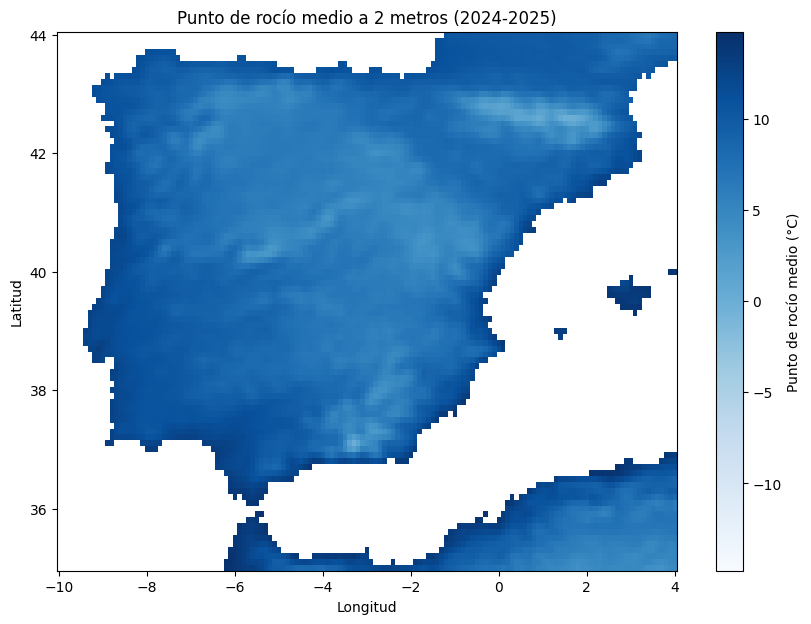

In [23]:
# mapa del punto de rocio
ruta_mapa_punto_rocio = (
    FIGURES_DIR / "mapa_punto_rocio_medio_2024_2025.png"
)

with xr.open_dataset(ruta_punto_rocio_medio) as ds:
    punto_rocio_medio = ds["punto_rocio_medio_c"].load()
    
punto_rocio_medio.plot(
    figsize=(10, 7),
    cmap="Blues",
    cbar_kwargs={
        "label": "Punto de rocío medio (°C)"
    }
)
plt.title(
    "Punto de rocío medio a 2 metros (2024-2025)"
)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.savefig(
    ruta_mapa_punto_rocio,
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [24]:
# punto de rocio en tres puntos de referencia
puntos_referencia = {
    "Madrid": (40.42, -3.70),
    "Lisboa": (38.72, -9.14),
    "Andorra la Vella": (42.51, 1.52),
}

config_rocio = VARIABLES_ESTADO["punto_rocio_2m"]
variable_rocio = config_rocio["xarray_name_expected"]
plantilla_rocio = config_rocio["file_template"]

datos_rocio = []
for year in YEARS:
    for month in MONTHS:
        ruta_archivo = RAW_DIR / plantilla_rocio.format(
            year=year,
            month=month,
        )

        with xr.open_dataset(ruta_archivo) as ds:
            rocio_c = (
                ds[variable_rocio].squeeze(drop=True)
                - 273.15
            )
            tiempo = (
                "valid_time"
                if "valid_time" in rocio_c.dims
                else "time"
            )

            for lugar, (latitud, longitud) in puntos_referencia.items():
                celda = rocio_c.sel(
                    latitude=latitud,
                    longitude=longitud,
                    method="nearest",
                )
                datos_rocio.append({
                    "lugar": lugar,
                    "year": int(year),
                    "month": int(month),
                    "punto_rocio_medio_c": float(
                        celda.mean(
                            dim=tiempo,
                            skipna=True,
                        ).values
                    ),
                    "latitud_rejilla": float(
                        celda["latitude"].values
                    ),
                    "longitud_rejilla": float(
                        celda["longitude"].values
                    ),
                })

rocio_puntos = pd.DataFrame(datos_rocio)

rocio_puntos["fecha"] = pd.to_datetime({
    "year": rocio_puntos["year"],
    "month": rocio_puntos["month"],
    "day": 1,
})

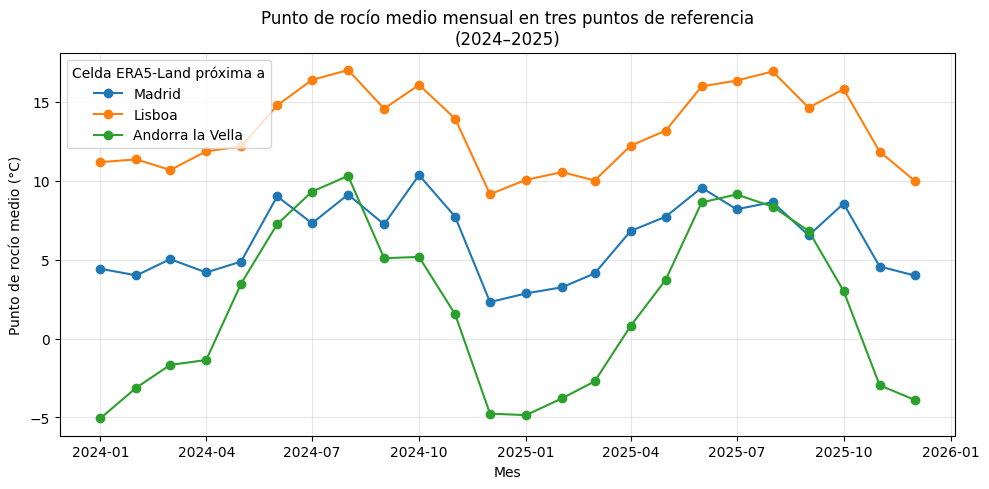

In [25]:
# Comparación mensual del punto de rocío
ruta_grafico_rocio = (
    FIGURES_DIR
    / "punto_rocio_puntos_referencia_2024_2025.png"
)

plt.figure(figsize=(10, 5))

for lugar in puntos_referencia:
    datos_lugar = rocio_puntos[
        rocio_puntos["lugar"] == lugar
    ]
    plt.plot(
        datos_lugar["fecha"],
        datos_lugar["punto_rocio_medio_c"],
        marker="o",
        label=lugar,
    )

plt.title(
    "Punto de rocío medio mensual en tres puntos de referencia\n"
    "(2024–2025)"
)
plt.xlabel("Mes")
plt.ylabel("Punto de rocío medio (°C)")
plt.legend(title="Celda ERA5-Land próxima a")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    ruta_grafico_rocio,
    dpi=300,
    bbox_inches="tight",
)
plt.show()



In [26]:
ruta_rocio_puntos = (
    METADATA_DIR
    / "punto_rocio_puntos_referencia_2024_2025.csv"
)
rocio_puntos.to_csv(
    ruta_rocio_puntos,
    index=False,
)
print("\nDatos guardados en:", ruta_rocio_puntos)


Datos guardados en: /kaggle/working/era5_land_2024_2025_v2/metadata/punto_rocio_puntos_referencia_2024_2025.csv


In [27]:
# Archivos de viento
archivos_u = sorted(
    INPUT_DIR.rglob("viento_u_10m_*.nc")
)
archivos_v = sorted(
    INPUT_DIR.rglob("viento_v_10m_*.nc")
)

total_esperado = len(YEARS) * len(MONTHS)

print("Archivos U:", len(archivos_u), "/", total_esperado)
print("Archivos V:", len(archivos_v), "/", total_esperado)

if len(archivos_u) != total_esperado:
    raise RuntimeError(
        f"Se esperaban {total_esperado} archivos U "
        f"y se encontraron {len(archivos_u)}."
    )

if len(archivos_v) != total_esperado:
    raise RuntimeError(
        f"Se esperaban {total_esperado} archivos V "
        f"y se encontraron {len(archivos_v)}."
    )

# U y V correspondan a los mismos meses
periodos_u = {
    ruta.stem.replace("viento_u_10m_", "")
    for ruta in archivos_u
}
periodos_v = {
    ruta.stem.replace("viento_v_10m_", "")
    for ruta in archivos_v
}
if periodos_u != periodos_v:
    raise RuntimeError(
        "U y V no corresponden a los mismos periodos."
    )
print("Carpeta:", archivos_u[0].parent)

Archivos U: 24 / 24
Archivos V: 24 / 24
Carpeta: /kaggle/input/datasets/aemjeloy/24h-copernicus/viento_10m_ERA5_Land_2024_2025_FINAL/dataset_viento_ERA5_Land_2024_2025/raw/u10


In [28]:
# recuperamos los archivos de viento
for ruta in archivos_u:
    destino = RAW_DIR / ruta.name
    if not destino.exists():
        shutil.copy2(ruta, destino)
        
for ruta in archivos_v:
    destino = RAW_DIR / ruta.name
    if not destino.exists():
        shutil.copy2(ruta, destino)
        
viento_u_raw = list(
    RAW_DIR.glob("viento_u_10m_*.nc")
)
viento_v_raw = list(
    RAW_DIR.glob("viento_v_10m_*.nc")
)

print("Viento U:", len(viento_u_raw), "de 24")
print("Viento V:", len(viento_v_raw), "de 24")

Viento U: 24 de 24
Viento V: 24 de 24


In [29]:
# componentes del viento
archivos_u = sorted(
    RAW_DIR.glob("viento_u_10m_*.nc")
)
archivos_v = sorted(
    RAW_DIR.glob("viento_v_10m_*.nc")
)
print("Componente U:", len(archivos_u), "de 24")
print("Componente V:", len(archivos_v), "de 24")

if len(archivos_u) == 24 and len(archivos_v) == 24:
    print("Datos de viento preparados.")
else:
    print(
        "Faltan archivos de viento. "
        "Se descargarán en las siguientes celdas."
    )

Componente U: 24 de 24
Componente V: 24 de 24
Datos de viento preparados.


In [30]:
# U del viento a 10 metros
rutas_viento_u, inventario_viento_u, ruta_inventario_viento_u = (
    descargar_periodo_variable(
        variable_key="viento_u_10m",
        tipo_variable="estado",
        max_reintentos=3
    )
)
print(
    "Componente U:",
    len(rutas_viento_u),
    "de 24 archivos"
)

[1/24] viento_u_10m: 2024-01
Archivo disponible: viento_u_10m_2024_01.nc
[2/24] viento_u_10m: 2024-02
Archivo disponible: viento_u_10m_2024_02.nc
[3/24] viento_u_10m: 2024-03
Archivo disponible: viento_u_10m_2024_03.nc
[4/24] viento_u_10m: 2024-04
Archivo disponible: viento_u_10m_2024_04.nc
[5/24] viento_u_10m: 2024-05
Archivo disponible: viento_u_10m_2024_05.nc
[6/24] viento_u_10m: 2024-06
Archivo disponible: viento_u_10m_2024_06.nc
[7/24] viento_u_10m: 2024-07
Archivo disponible: viento_u_10m_2024_07.nc
[8/24] viento_u_10m: 2024-08
Archivo disponible: viento_u_10m_2024_08.nc
[9/24] viento_u_10m: 2024-09
Archivo disponible: viento_u_10m_2024_09.nc
[10/24] viento_u_10m: 2024-10
Archivo disponible: viento_u_10m_2024_10.nc
[11/24] viento_u_10m: 2024-11
Archivo disponible: viento_u_10m_2024_11.nc
[12/24] viento_u_10m: 2024-12
Archivo disponible: viento_u_10m_2024_12.nc
[13/24] viento_u_10m: 2025-01
Archivo disponible: viento_u_10m_2025_01.nc
[14/24] viento_u_10m: 2025-02
Archivo disponibl

In [31]:
# V del viento a 10 metros
rutas_viento_v, inventario_viento_v, ruta_inventario_viento_v = (
    descargar_periodo_variable(
        variable_key="viento_v_10m",
        tipo_variable="estado",
        max_reintentos=3
    )
)
print(
    "Componente V:",
    len(rutas_viento_v),
    "de 24 archivos"
)

[1/24] viento_v_10m: 2024-01
Archivo disponible: viento_v_10m_2024_01.nc
[2/24] viento_v_10m: 2024-02
Archivo disponible: viento_v_10m_2024_02.nc
[3/24] viento_v_10m: 2024-03
Archivo disponible: viento_v_10m_2024_03.nc
[4/24] viento_v_10m: 2024-04
Archivo disponible: viento_v_10m_2024_04.nc
[5/24] viento_v_10m: 2024-05
Archivo disponible: viento_v_10m_2024_05.nc
[6/24] viento_v_10m: 2024-06
Archivo disponible: viento_v_10m_2024_06.nc
[7/24] viento_v_10m: 2024-07
Archivo disponible: viento_v_10m_2024_07.nc
[8/24] viento_v_10m: 2024-08
Archivo disponible: viento_v_10m_2024_08.nc
[9/24] viento_v_10m: 2024-09
Archivo disponible: viento_v_10m_2024_09.nc
[10/24] viento_v_10m: 2024-10
Archivo disponible: viento_v_10m_2024_10.nc
[11/24] viento_v_10m: 2024-11
Archivo disponible: viento_v_10m_2024_11.nc
[12/24] viento_v_10m: 2024-12
Archivo disponible: viento_v_10m_2024_12.nc
[13/24] viento_v_10m: 2025-01
Archivo disponible: viento_v_10m_2025_01.nc
[14/24] viento_v_10m: 2025-02
Archivo disponibl

In [32]:
# velocidad media del viento a 10 m
resumen_viento = []
suma_viento = conteo_viento = None

for year in YEARS:
    for month in MONTHS:
        ruta_u = RAW_DIR / f"viento_u_10m_{year}_{month}.nc"
        ruta_v = RAW_DIR / f"viento_v_10m_{year}_{month}.nc"

        with xr.open_dataset(ruta_u) as ds_u, xr.open_dataset(ruta_v) as ds_v:
            # Velocidad del viento: sqrt(U² + V²)
            velocidad = np.hypot(ds_u["u10"], ds_v["v10"])
            tiempo = (
                "valid_time"
                if "valid_time" in velocidad.dims
                else "time"
            )

            resumen_viento.append({
                "year": int(year),
                "month": int(month),
                "media_ms": float(
                    velocidad.mean(skipna=True).values
                ),
            })

            suma_mes = velocidad.sum(
                dim=tiempo,
                skipna=True,
            ).load()

            conteo_mes = velocidad.count(
                dim=tiempo,
            ).load()

        if suma_viento is None:
            suma_viento = suma_mes
            conteo_viento = conteo_mes
        else:
            suma_viento += suma_mes
            conteo_viento += conteo_mes

# Media temporal por celda
resumen_viento = pd.DataFrame(resumen_viento)
velocidad_viento_media = (
    suma_viento / conteo_viento
).where(conteo_viento > 0)
velocidad_viento_media.name = (
    "velocidad_viento_media_10m_ms"
)

# guardamos resultados
ruta_viento_medio = (
    PROCESSED_DIR
    / "derived"
    / "velocidad_viento_media_10m_2024_2025.nc"
)
velocidad_viento_media.to_netcdf(
    ruta_viento_medio
)
resumen_viento.to_csv(
    METADATA_DIR / "resumen_viento_10m_2024_2025.csv",
    index=False,
)

# Cobertura temporal: 731 días × 24 horas
horas_esperadas = 17544
celdas_completas = int(
    (conteo_viento == horas_esperadas).sum().item()
)
celdas_sin_datos = int(
    (conteo_viento == 0).sum().item()
)
celdas_parciales = int(
    (
        (conteo_viento > 0)
        & (conteo_viento < horas_esperadas)
    ).sum().item()
)
print(
    f"Meses procesados: {len(resumen_viento)}\n"
    f"Celdas completas: {celdas_completas}\n"
    f"Celdas parciales: {celdas_parciales}\n"
    f"Celdas sin datos: {celdas_sin_datos}\n"
    f"Capa guardada en: {ruta_viento_medio}"
)

Meses procesados: 24
Celdas completas: 7831
Celdas parciales: 0
Celdas sin datos: 5000
Capa guardada en: /kaggle/working/era5_land_2024_2025_v2/processed/derived/velocidad_viento_media_10m_2024_2025.nc


### Resultado del procesamiento del viento

La velocidad del viento a 10 m se calculó a partir de las componentes U y V.

De las 12.831 celdas de la rejilla, 7.831 presentan cobertura temporal completa y ninguna tiene cobertura parcial. Las 5.000 celdas restantes no presentan valores válidos durante el periodo analizado.

La capa de salida contiene la velocidad media del viento a 10 m, expresada en m/s.

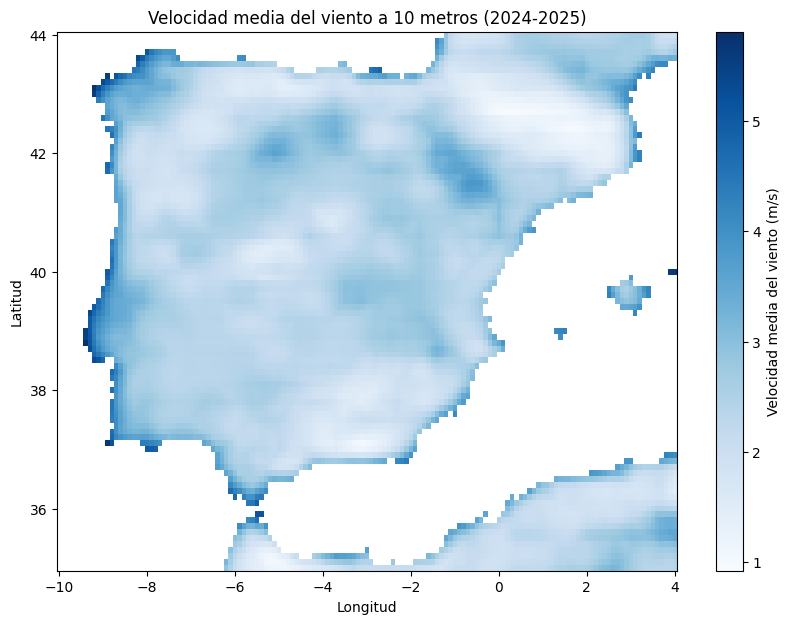

Celdas con datos: 7831
Celdas sin datos: 5000


In [33]:
# mapa de la velocidad del viento
ruta_mapa_viento = (
    FIGURES_DIR / "mapa_velocidad_viento_media_2024_2025.png"
)

with xr.open_dataset(ruta_viento_medio) as ds:
    viento_medio = ds["velocidad_viento_media_10m_ms"].load()
    
viento_medio.plot(
    figsize=(10, 7),
    cmap="Blues",
    cbar_kwargs={
        "label": "Velocidad media del viento (m/s)"
    }
)
plt.title(
    "Velocidad media del viento a 10 metros (2024-2025)"
)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.savefig(
    ruta_mapa_viento,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(
    "Celdas con datos:",
    int(viento_medio.notnull().sum().values)
)
print(
    "Celdas sin datos:",
    int(viento_medio.isnull().sum().values)
)


In [34]:
# Viento mensual en tres puntos de referencia
datos_viento_puntos = []

for year in YEARS:
    for month in MONTHS:
        archivo_u = RAW_DIR / f"viento_u_10m_{year}_{month}.nc"
        archivo_v = RAW_DIR / f"viento_v_10m_{year}_{month}.nc"

        with xr.open_dataset(archivo_u) as ds_u, xr.open_dataset(archivo_v) as ds_v:
            u = ds_u["u10"].squeeze(drop=True)
            v = ds_v["v10"].squeeze(drop=True)
            velocidad = np.hypot(u, v)

            tiempo = (
                "valid_time"
                if "valid_time" in velocidad.dims
                else "time"
            )

            for lugar, (latitud, longitud) in puntos_referencia.items():
                punto = velocidad.sel(
                    latitude=latitud,
                    longitude=longitud,
                    method="nearest"
                )

                datos_viento_puntos.append({
                    "lugar": lugar,
                    "year": year,
                    "month": month,
                    "velocidad_media_ms": float(
                        punto.mean(tiempo, skipna=True).item()
                    ),
                    "latitud_rejilla": float(
                        punto["latitude"].item()
                    ),
                    "longitud_rejilla": float(
                        punto["longitude"].item()
                    )
                })

viento_puntos = pd.DataFrame(datos_viento_puntos)

viento_puntos["fecha"] = pd.to_datetime(
    viento_puntos[["year", "month"]].assign(day=1)
)

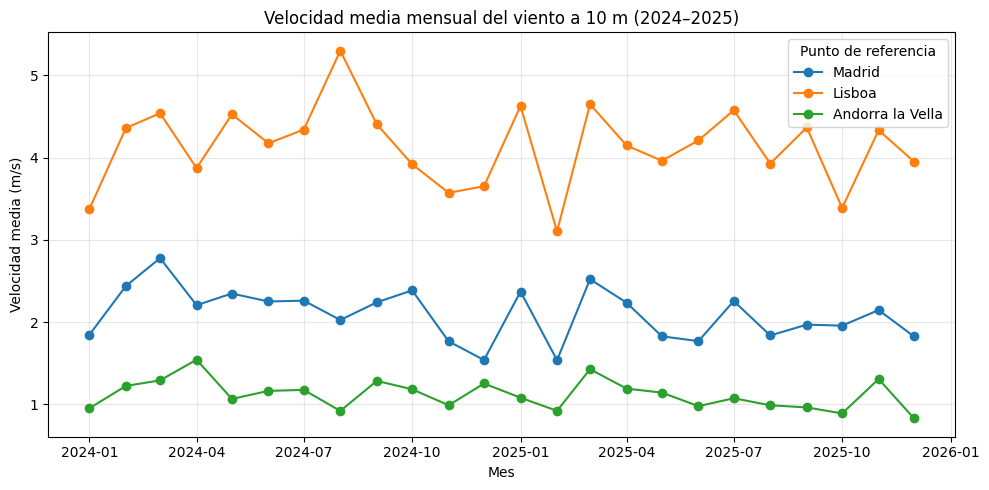

In [35]:
# Gráfico mensual del viento en los puntos seleccionados
ruta_grafico_viento_puntos = (
    FIGURES_DIR / "viento_puntos_referencia_2024_2025.png"
)

plt.figure(figsize=(10, 5))

for lugar in viento_puntos["lugar"].unique():
    datos = viento_puntos[
        viento_puntos["lugar"] == lugar
    ].sort_values("fecha")

    plt.plot(
        datos["fecha"],
        datos["velocidad_media_ms"],
        marker="o",
        label=lugar
    )
plt.title("Velocidad media mensual del viento a 10 m (2024–2025)")
plt.xlabel("Mes")
plt.ylabel("Velocidad media (m/s)")
plt.legend(title="Punto de referencia")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    ruta_grafico_viento_puntos,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Velocidad del viento en puntos de referencia

Se muestra la velocidad media mensual del viento a 10 m en las celdas ERA5-Land más próximas a Madrid, Lisboa y Andorra la Vella. Para cada mes calculamos primero la velocidad a partir de las componentes U y V y posteriormente obtenemos la media de todos los registros horarios de la celda.

Las tres localizaciones nos permiten comparar un entorno interior, uno atlántico y uno pirenaico. Los valores no corresponden a estaciones meteorológicas ni representan las medias de España, Portugal o Andorra.

In [36]:
ruta_viento_puntos = (
    METADATA_DIR
    / "viento_puntos_referencia_2024_2025.csv"
)
viento_puntos.to_csv(
    ruta_viento_puntos,
    index=False,
)
print("Datos guardados en:", ruta_viento_puntos)

Datos guardados en: /kaggle/working/era5_land_2024_2025_v2/metadata/viento_puntos_referencia_2024_2025.csv


In [37]:
# humedad en la superficie del suelo

# Recuperamos los archivos de Kaggle
archivos_humedad_input = sorted(
    INPUT_DIR.rglob("humedad_suelo_superficial_20??_??.nc")
)

for ruta in archivos_humedad_input:
    destino = RAW_DIR / ruta.name
    if not destino.exists():
        shutil.copy2(ruta, destino)
print(
    "Archivos recuperados desde Input:",
    len(archivos_humedad_input)
)

# Comprobamos los 24 meses
rutas_humedad, inventario_humedad, ruta_inventario_humedad = (
    descargar_periodo_variable(
        variable_key="humedad_suelo_superficial",
        tipo_variable="estado",
        max_reintentos=3
    )
)
print(
    "Humedad del suelo:",
    len(rutas_humedad),
    "de 24 archivos"
)

Archivos recuperados desde Input: 24
[1/24] humedad_suelo_superficial: 2024-01
Archivo disponible: humedad_suelo_superficial_2024_01.nc
[2/24] humedad_suelo_superficial: 2024-02
Archivo disponible: humedad_suelo_superficial_2024_02.nc
[3/24] humedad_suelo_superficial: 2024-03
Archivo disponible: humedad_suelo_superficial_2024_03.nc
[4/24] humedad_suelo_superficial: 2024-04
Archivo disponible: humedad_suelo_superficial_2024_04.nc
[5/24] humedad_suelo_superficial: 2024-05
Archivo disponible: humedad_suelo_superficial_2024_05.nc
[6/24] humedad_suelo_superficial: 2024-06
Archivo disponible: humedad_suelo_superficial_2024_06.nc
[7/24] humedad_suelo_superficial: 2024-07
Archivo disponible: humedad_suelo_superficial_2024_07.nc
[8/24] humedad_suelo_superficial: 2024-08
Archivo disponible: humedad_suelo_superficial_2024_08.nc
[9/24] humedad_suelo_superficial: 2024-09
Archivo disponible: humedad_suelo_superficial_2024_09.nc
[10/24] humedad_suelo_superficial: 2024-10
Archivo disponible: humedad_s

In [38]:
# proceso de la humedad ddel suelo
resumen_humedad = []
suma_humedad = None
conteo_humedad = None

for year in YEARS:
    for month in MONTHS:
        ruta = RAW_DIR / f"humedad_suelo_superficial_{year}_{month}.nc"

        with xr.open_dataset(ruta) as ds:
            humedad = ds["swvl1"]

            if "valid_time" in humedad.dims:
                tiempo = "valid_time"
            else:
                tiempo = "time"

            resumen_humedad.append({
                "year": int(year),
                "month": int(month),
                "media_m3_m3": float(humedad.mean().values)
            })

            suma_mes = humedad.sum(dim=tiempo).load()
            conteo_mes = humedad.count(dim=tiempo).load()
            if suma_humedad is None:
                suma_humedad = suma_mes
                conteo_humedad = conteo_mes
            else:
                suma_humedad += suma_mes
                conteo_humedad += conteo_mes
                
resumen_humedad = pd.DataFrame(resumen_humedad)

# Media del periodo
humedad_media = suma_humedad / conteo_humedad
humedad_media.name = "soil_moisture_mean_2024_2025"
ruta_humedad_media = (
    PROCESSED_DIR / "derived"
    / "humedad_suelo_superficial_media_2024_2025.nc"
)
humedad_media.to_netcdf(ruta_humedad_media)

print("Meses procesados:", len(resumen_humedad))
print(
    "Celdas completas:",
    int((conteo_humedad == 17544).sum().values)
)
print(
    "Celdas parciales:",
    int(
        ((conteo_humedad > 0) & (conteo_humedad < 17544))
        .sum().values
    )
)


Meses procesados: 24
Celdas completas: 7831
Celdas parciales: 0


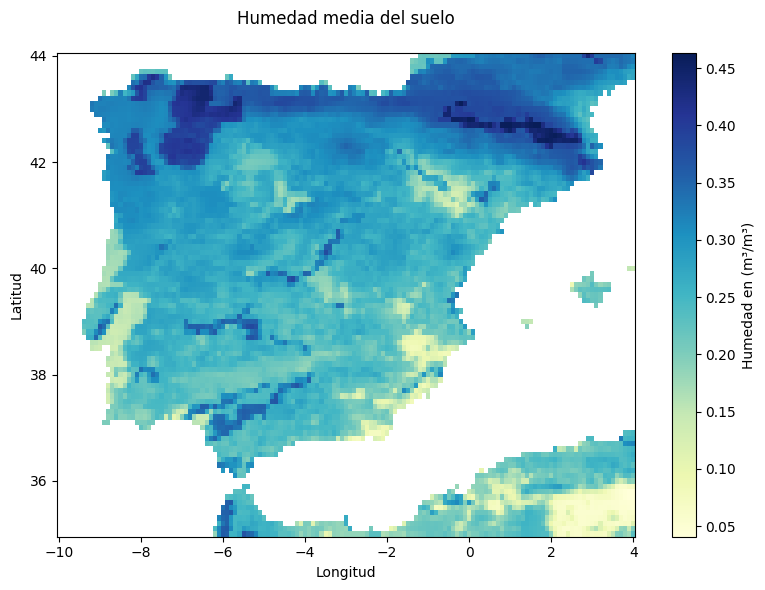

In [39]:
# Mapa de la humedad superficial media del suelo
ruta_humedad_media = (
    PROCESSED_DIR
    / "derived"
    / "humedad_suelo_superficial_media_2024_2025.nc"
)

with xr.open_dataset(ruta_humedad_media) as ds:
    humedad_media = ds[
        "soil_moisture_mean_2024_2025"
    ].load()

ruta_mapa_humedad = (
    FIGURES_DIR
    / "mapa_humedad_suelo_superficial_2024_2025.png"
)

plt.figure(figsize=(8, 6))
humedad_media.plot(
    x="longitude",
    y="latitude",
    cmap="YlGnBu",
    cbar_kwargs={
        "label": "Humedad en (m³/m³)"
    },
)
plt.title(
    "Humedad media del suelo\n"
)
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.tight_layout()
plt.savefig(
    ruta_mapa_humedad,
    dpi=300,
    bbox_inches="tight",
)
plt.show()



In [40]:
# Humedad mensual en tres puntos de referencia
config_humedad = VARIABLES_ESTADO[
    "humedad_suelo_superficial"
]
variable_humedad = config_humedad[
    "xarray_name_expected"
]
plantilla_humedad = config_humedad[
    "file_template"
]

datos_humedad_puntos = []

for year in YEARS:
    for month in MONTHS:
        ruta_archivo = RAW_DIR / plantilla_humedad.format(
            year=year,
            month=month,
        )

        with xr.open_dataset(ruta_archivo) as ds:
            humedad = ds[
                variable_humedad
            ].squeeze(drop=True)

            tiempo = (
                "valid_time"
                if "valid_time" in humedad.dims
                else "time"
            )

            for lugar, coordenadas in puntos_referencia.items():
                latitud, longitud = coordenadas

                punto = humedad.sel(
                    latitude=latitud,
                    longitude=longitud,
                    method="nearest",
                )

                datos_humedad_puntos.append({
                    "lugar": lugar,
                    "year": year,
                    "month": month,
                    "humedad_media_m3_m3": float(
                        punto.mean(
                            tiempo,
                            skipna=True,
                        ).item()
                    ),
                    "latitud_rejilla": float(
                        punto["latitude"].item()
                    ),
                    "longitud_rejilla": float(
                        punto["longitude"].item()
                    ),
                })

humedad_puntos = pd.DataFrame(
    datos_humedad_puntos
)
humedad_puntos["fecha"] = pd.to_datetime(
    humedad_puntos[
        ["year", "month"]
    ].assign(day=1)
)

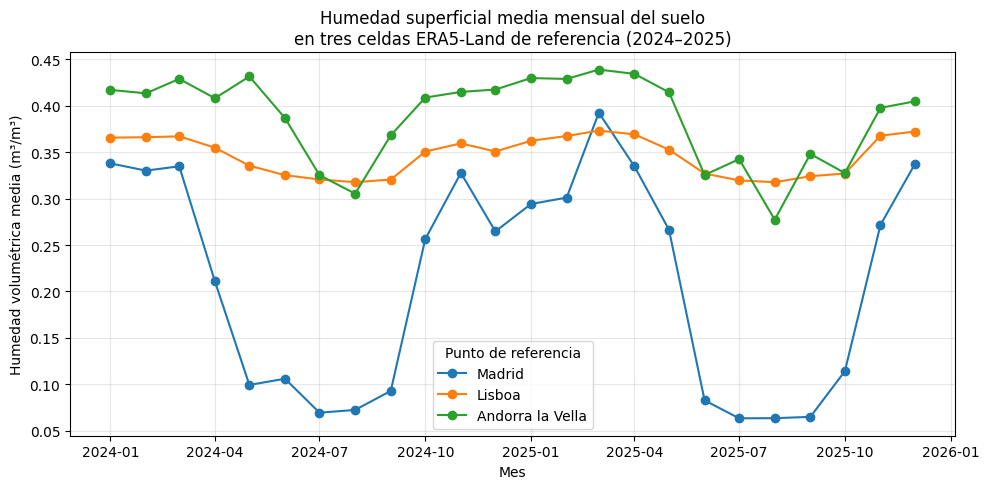

In [41]:
# Gráfico mensual de humedad en tres puntos
ruta_grafico_humedad_puntos = (
    FIGURES_DIR
    / "humedad_suelo_puntos_referencia_2024_2025.png"
)

plt.figure(figsize=(10, 5))

for lugar in humedad_puntos["lugar"].unique():
    datos = humedad_puntos[
        humedad_puntos["lugar"] == lugar
    ].sort_values("fecha")
    plt.plot(
        datos["fecha"],
        datos["humedad_media_m3_m3"],
        marker="o",
        label=lugar,
    )

plt.title(
    "Humedad superficial media mensual del suelo\n"
    "en tres celdas ERA5-Land de referencia (2024–2025)"
)
plt.xlabel("Mes")
plt.ylabel("Humedad volumétrica media (m³/m³)")
plt.legend(title="Punto de referencia")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    ruta_grafico_humedad_puntos,
    dpi=300,
    bbox_inches="tight",
)
plt.show()


In [42]:
ruta_humedad_puntos = (
    METADATA_DIR
    / "humedad_suelo_puntos_referencia_2024_2025.csv"
)
humedad_puntos.to_csv(
    ruta_humedad_puntos,
    index=False,
)
print("Datos guardados en:", ruta_humedad_puntos)

Datos guardados en: /kaggle/working/era5_land_2024_2025_v2/metadata/humedad_suelo_puntos_referencia_2024_2025.csv


In [43]:
# Precipitación de 2024-2025
total_esperado = len(YEARS) * len(MONTHS)
year_auxiliar = str(int(YEARS[-1]) + 1)
month_auxiliar = "01"

# Archivos 
nombres_necesarios = {
    f"precipitacion_total_{year}_{month}.nc"
    for year in YEARS
    for month in MONTHS
}

nombres_necesarios.add(
    f"precipitacion_total_{year_auxiliar}_{month_auxiliar}.nc"
)

# Recuperamos de Kaggle Input los archivos
archivos_input = {
    ruta.name: ruta
    for ruta in INPUT_DIR.rglob("precipitacion_total_*.nc")
    if ruta.name in nombres_necesarios
}
copiados = 0

for nombre, origen in archivos_input.items():
    destino = RAW_DIR / nombre
    if not destino.exists():
        shutil.copy2(origen, destino)
        copiados += 1

# Archivos principales
rutas_precipitacion, inventario_precipitacion, ruta_inventario_precipitacion = (
    descargar_periodo_variable(
        variable_key="precipitacion_total",
        tipo_variable="acumulada",
        max_reintentos=3,
    )
)

# Enero siguiente permite completar el 31 de diciembre
ruta_precipitacion_auxiliar = descargar_variable_mensual(
    variable_key="precipitacion_total",
    tipo_variable="acumulada",
    year=year_auxiliar,
    month=month_auxiliar,
    max_reintentos=3,
)

if len(rutas_precipitacion) != total_esperado:
    raise RuntimeError(
        f"Se esperaban {total_esperado} archivos principales "
        f"y se obtuvieron {len(rutas_precipitacion)}."
    )

print(
    f"Archivos disponibles en Input: {len(archivos_input)}\n"
    f"Archivos copiados a RAW: {copiados}\n"
    f"Periodo principal: {len(rutas_precipitacion)}/{total_esperado}\n"
    f"Archivo auxiliar: {ruta_precipitacion_auxiliar.name}"
)

[1/24] precipitacion_total: 2024-01
Archivo disponible: precipitacion_total_2024_01.nc
[2/24] precipitacion_total: 2024-02
Archivo disponible: precipitacion_total_2024_02.nc
[3/24] precipitacion_total: 2024-03
Archivo disponible: precipitacion_total_2024_03.nc
[4/24] precipitacion_total: 2024-04
Archivo disponible: precipitacion_total_2024_04.nc
[5/24] precipitacion_total: 2024-05
Archivo disponible: precipitacion_total_2024_05.nc
[6/24] precipitacion_total: 2024-06
Archivo disponible: precipitacion_total_2024_06.nc
[7/24] precipitacion_total: 2024-07
Archivo disponible: precipitacion_total_2024_07.nc
[8/24] precipitacion_total: 2024-08
Archivo disponible: precipitacion_total_2024_08.nc
[9/24] precipitacion_total: 2024-09
Archivo disponible: precipitacion_total_2024_09.nc
[10/24] precipitacion_total: 2024-10
Archivo disponible: precipitacion_total_2024_10.nc
[11/24] precipitacion_total: 2024-11
Archivo disponible: precipitacion_total_2024_11.nc
[12/24] precipitacion_total: 2024-12
Arch

In [44]:
# proceso de la precipitacion
datos = []
rutas = rutas_precipitacion + [ruta_precipitacion_auxiliar]

for ruta in rutas:
    with xr.open_dataset(ruta) as ds:
        precipitacion = ds["tp"] * 1000  # m -> mm
        if "valid_time" in precipitacion.dims:
            tiempo = "valid_time"
        else:
            tiempo = "time"
        fechas = (
            pd.to_datetime(precipitacion[tiempo].values)
            - pd.Timedelta(days=1)
        )
        precipitacion = precipitacion.assign_coords(
            {tiempo: fechas}
        ).load()
        datos.append(precipitacion)

# Unimos los 25 archivos
precipitacion_diaria = xr.concat(
    datos,
    dim=tiempo
).sortby(tiempo)
precipitacion_diaria = precipitacion_diaria.sel(
    {tiempo: slice("2024-01-01", "2025-12-31")}
)
conteo_precipitacion = precipitacion_diaria.count(dim=tiempo)

# Variables finales
precipitacion_total = precipitacion_diaria.sum(
    dim=tiempo,
    skipna=True,
    min_count=1
)
precipitacion_media = precipitacion_diaria.mean(
    dim=tiempo,
    skipna=True
)
precipitacion_total.name = "precipitation_total_mm_2024_2025"
precipitacion_media.name = "precipitation_daily_mean_mm_2024_2025"
ruta_precipitacion_final = (
    PROCESSED_DIR / "derived"
    / "precipitacion_total_capas_espaciales_2024_2025.nc"
)

xr.Dataset({
    precipitacion_total.name: precipitacion_total,
    precipitacion_media.name: precipitacion_media
}).to_netcdf(ruta_precipitacion_final)

print("Días procesados:", precipitacion_diaria.sizes[tiempo])
print(
    "Celdas completas:",
    int((conteo_precipitacion == 731).sum().values)
)
print(
    "Celdas parciales:",
    int(
        ((conteo_precipitacion > 0) &
         (conteo_precipitacion < 731)).sum().values
    )
)
print(
    "Mínimo diario:",
    round(float(precipitacion_diaria.min().values), 6),
    "mm"
)


Días procesados: 731
Celdas completas: 7831
Celdas parciales: 0
Mínimo diario: 0.0 mm


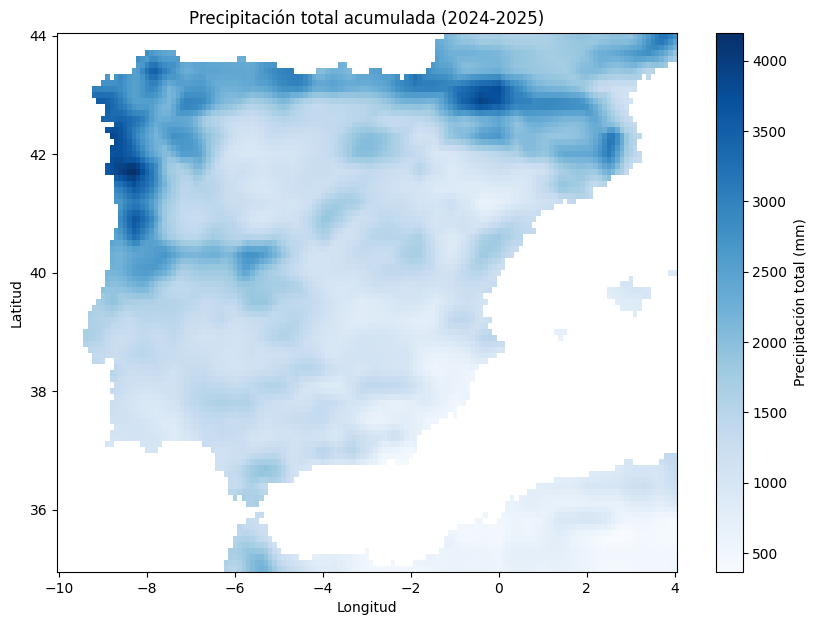

Celdas representadas: 7831


In [45]:
# mapa de la precipitacion 2024-2025
ruta_mapa_precipitacion = (
    FIGURES_DIR / "precipitacion_total_mapa_acumulada_2024_2025.png"
)

with xr.open_dataset(ruta_precipitacion_final) as ds:
    precipitacion_mapa = ds[
        "precipitation_total_mm_2024_2025"
    ].load()
precipitacion_mapa.plot(
    figsize=(10, 7),
    cmap="Blues",
    cbar_kwargs={
        "label": "Precipitación total (mm)"
    }
)
plt.title(
    "Precipitación total acumulada (2024-2025)"
)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.savefig(
    ruta_mapa_precipitacion,
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print(
    "Celdas representadas:",
    int(precipitacion_mapa.notnull().sum().values)
)


In [46]:
# Precipitación mensual en tres puntos de referencia
precipitacion_mensual = precipitacion_diaria.sel(
    {tiempo: slice("2024-01-01", "2025-12-31")}
)
precipitacion_mensual = precipitacion_mensual.resample(
    {tiempo: "MS"}
).sum(
    skipna=True,
    min_count=1
)
precipitacion_puntos = pd.DataFrame({
    "fecha": pd.to_datetime(
        precipitacion_mensual[tiempo].values
    )
})

for lugar, (latitud, longitud) in puntos_referencia.items():
    serie_lugar = precipitacion_mensual.sel(
        latitude=latitud,
        longitude=longitud,
        method="nearest"
    )
    precipitacion_puntos[lugar] = serie_lugar.values

ruta_precipitacion_puntos = (
    METADATA_DIR
    / "precipitacion_puntos_referencia_2024_2025.csv"
)
precipitacion_puntos.to_csv(
    ruta_precipitacion_puntos,
    index=False
)

print("Meses guardados:", len(precipitacion_puntos))


Meses guardados: 24


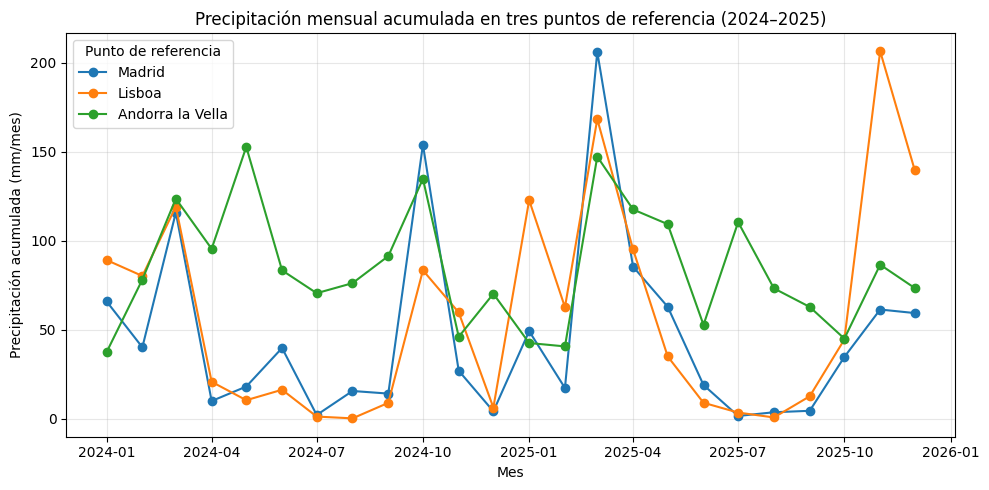

In [47]:
# Precipitación mensual en los puntos de referencia
ruta_grafico_precipitacion = (
    FIGURES_DIR
    / "precipitacion_puntos_referencia_2024_2025.png"
)

plt.figure(figsize=(10, 5))
for lugar in ["Madrid", "Lisboa", "Andorra la Vella"]:
    plt.plot(
        precipitacion_puntos["fecha"],
        precipitacion_puntos[lugar],
        marker="o",
        label=lugar
    )
plt.title(
    "Precipitación mensual acumulada en tres puntos de referencia "
    "(2024–2025)"
)
plt.xlabel("Mes")
plt.ylabel("Precipitación acumulada (mm/mes)")
plt.legend(title="Punto de referencia")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    ruta_grafico_precipitacion,
    dpi=300,
    bbox_inches="tight"
)
plt.show()



### Radiación solar descendente

ERA5-Land proporciona la radiación solar descendente en superficie (`ssrd`) como una variable acumulada, expresada en J/m².

Para el análisis convertimos los valores a MJ/m² y aplicamos el tratamiento temporal usado para la precipitación, asignando cada acumulación al día correspondiente.

Además de los 24 archivos mensuales de 2024 y 2025, conservamos enero de 2026 como archivo auxiliar para completar correctamente el último día del periodo analizado.

In [48]:
# radiacion solar 2024-2025

# Recuperamos los archivos 
for ruta in INPUT_DIR.rglob("radiacion_solar_20??_??.nc"):
    destino = RAW_DIR / ruta.name
    if not destino.exists():
        shutil.copy2(ruta, destino)

# 24 meses de 2024-2025
rutas_radiacion, _, _ = descargar_periodo_variable(
    variable_key="radiacion_solar",
    tipo_variable="acumulada",
    max_reintentos=3
)

# Enero de 2026 para completar el último día de 2025
ruta_radiacion_auxiliar = descargar_variable_mensual(
    variable_key="radiacion_solar",
    tipo_variable="acumulada",
    year="2026",
    month="01",
    max_reintentos=3
)
print("Radiación:", len(rutas_radiacion), "de 24 archivos")
print("Auxiliar:", ruta_radiacion_auxiliar.name)

[1/24] radiacion_solar: 2024-01
Archivo disponible: radiacion_solar_2024_01.nc
[2/24] radiacion_solar: 2024-02
Archivo disponible: radiacion_solar_2024_02.nc
[3/24] radiacion_solar: 2024-03
Archivo disponible: radiacion_solar_2024_03.nc
[4/24] radiacion_solar: 2024-04
Archivo disponible: radiacion_solar_2024_04.nc
[5/24] radiacion_solar: 2024-05
Archivo disponible: radiacion_solar_2024_05.nc
[6/24] radiacion_solar: 2024-06
Archivo disponible: radiacion_solar_2024_06.nc
[7/24] radiacion_solar: 2024-07
Archivo disponible: radiacion_solar_2024_07.nc
[8/24] radiacion_solar: 2024-08
Archivo disponible: radiacion_solar_2024_08.nc
[9/24] radiacion_solar: 2024-09
Archivo disponible: radiacion_solar_2024_09.nc
[10/24] radiacion_solar: 2024-10
Archivo disponible: radiacion_solar_2024_10.nc
[11/24] radiacion_solar: 2024-11
Archivo disponible: radiacion_solar_2024_11.nc
[12/24] radiacion_solar: 2024-12
Archivo disponible: radiacion_solar_2024_12.nc
[13/24] radiacion_solar: 2025-01
Archivo disponib

In [49]:
# Proceso de la radiación solar
datos_radiacion = []
rutas_radiacion_completas = (
    rutas_radiacion + [ruta_radiacion_auxiliar]
)

dias_esperados = 731

for ruta in rutas_radiacion_completas:
    with xr.open_dataset(ruta) as ds:
        # J/m² -> MJ/m²
        radiacion = ds["ssrd"] / 1_000_000
        tiempo = (
            "valid_time"
            if "valid_time" in radiacion.dims
            else "time"
        )

        # El valor de las 00:00 corresponde al día anterior
        fechas = (
            pd.to_datetime(radiacion[tiempo].values)
            - pd.Timedelta(days=1)
        )
        radiacion = radiacion.assign_coords(
            {tiempo: fechas}
        ).load()
        datos_radiacion.append(radiacion)

# Unimos los archivos y dejamos 2024-2025
radiacion_diaria = xr.concat(
    datos_radiacion,
    dim=tiempo
).sortby(tiempo)
radiacion_diaria = radiacion_diaria.sel(
    {tiempo: slice("2024-01-01", "2025-12-31")}
)

if radiacion_diaria.sizes[tiempo] != dias_esperados:
    raise RuntimeError(
        f"Se esperaban {dias_esperados} días y se obtuvieron "
        f"{radiacion_diaria.sizes[tiempo]}."
    )
conteo_radiacion = radiacion_diaria.count(
    dim=tiempo
)

# Capas espaciales
radiacion_total = radiacion_diaria.sum(
    dim=tiempo,
    skipna=True,
    min_count=1
)
radiacion_media = radiacion_diaria.mean(
    dim=tiempo,
    skipna=True
)
radiacion_total.name = (
    "solar_radiation_total_mj_m2_2024_2025"
)
radiacion_media.name = (
    "solar_radiation_daily_mean_mj_m2_2024_2025"
)
ruta_radiacion_final = (
    PROCESSED_DIR
    / "derived"
    / "radiacion_solar_capas_espaciales_2024_2025.nc"
)

xr.Dataset({
    radiacion_total.name: radiacion_total,
    radiacion_media.name: radiacion_media
}).to_netcdf(
    ruta_radiacion_final
)
celdas_completas = int(
    (conteo_radiacion == dias_esperados).sum().item()
)
celdas_parciales = int(
    (
        (conteo_radiacion > 0)
        & (conteo_radiacion < dias_esperados)
    ).sum().item()
)

print(
    f"Días procesados: {radiacion_diaria.sizes[tiempo]}\n"
    f"Celdas completas: {celdas_completas}\n"
    f"Celdas parciales: {celdas_parciales}\n"
    f"Archivo guardado en: {ruta_radiacion_final}"
)

Días procesados: 731
Celdas completas: 7831
Celdas parciales: 0
Archivo guardado en: /kaggle/working/era5_land_2024_2025_v2/processed/derived/radiacion_solar_capas_espaciales_2024_2025.nc


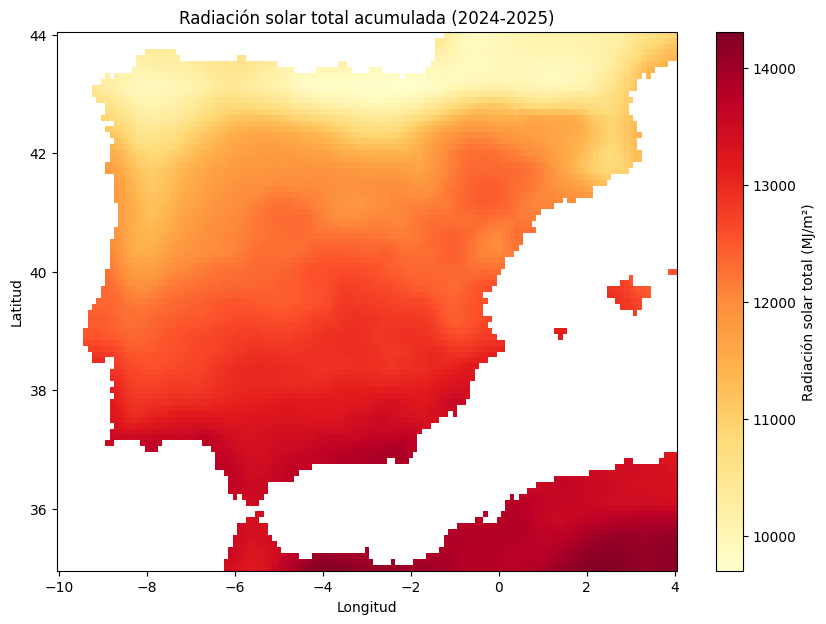

Celdas representadas: 7831


In [50]:
# mapa de radiacion solar 2024-2025
ruta_mapa_radiacion = (
    FIGURES_DIR / "radiacion_solar_mapa_acumulada_2024_2025.png"
)

with xr.open_dataset(ruta_radiacion_final) as ds:
    radiacion_mapa = ds[
        "solar_radiation_total_mj_m2_2024_2025"
    ].load()
radiacion_mapa.plot(
    figsize=(10, 7),
    cmap="YlOrRd",
    cbar_kwargs={
        "label": "Radiación solar total (MJ/m²)"
    }
)
plt.title(
    "Radiación solar total acumulada (2024-2025)"
)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.savefig(
    ruta_mapa_radiacion,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(
    "Celdas representadas:",
    int(radiacion_mapa.notnull().sum().values)
)


In [51]:
# Radiación solar mensual en tres puntos de referencia
radiacion_mensual = radiacion_diaria.resample(
    {tiempo: "MS"}
).sum(
    skipna=True,
    min_count=1
)
radiacion_puntos = pd.DataFrame({
    "fecha": pd.to_datetime(
        radiacion_mensual[tiempo].values
    )
})

for lugar, (latitud, longitud) in puntos_referencia.items():
    radiacion_lugar = radiacion_mensual.sel(
        latitude=latitud,
        longitude=longitud,
        method="nearest"
    )
    radiacion_puntos[lugar] = radiacion_lugar.values

ruta_radiacion_puntos = (
    METADATA_DIR
    / "radiacion_solar_puntos_referencia_2024_2025.csv"
)

radiacion_puntos.to_csv(
    ruta_radiacion_puntos,
    index=False
)

print("Meses guardados:", len(radiacion_puntos))


Meses guardados: 24


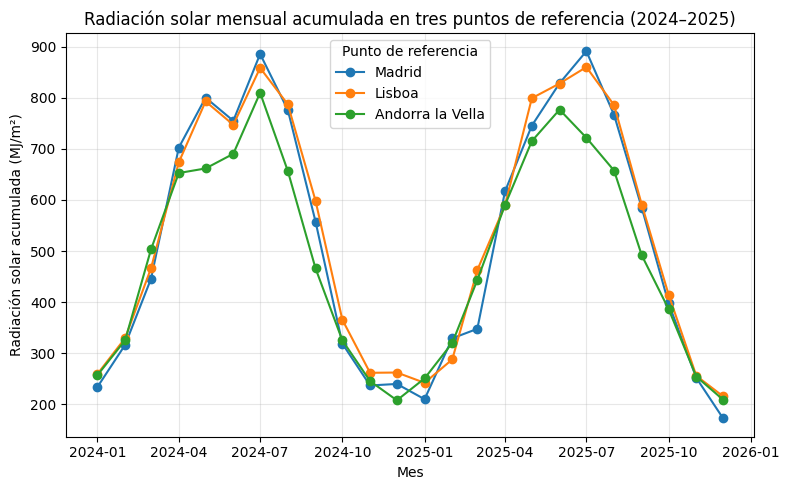

In [52]:
# Radiación solar mensual en los puntos seleccionados
ruta_grafico_radiacion = (
    FIGURES_DIR
    / "radiacion_solar_puntos_referencia_2024_2025.png"
)

plt.figure(figsize=(8, 5))

for lugar in ["Madrid", "Lisboa", "Andorra la Vella"]:
    plt.plot(
        radiacion_puntos["fecha"],
        radiacion_puntos[lugar],
        marker="o",
        label=lugar
    )

plt.title(
    "Radiación solar mensual acumulada en tres puntos de referencia "
    "(2024–2025)"
)
plt.xlabel("Mes")
plt.ylabel("Radiación solar acumulada (MJ/m²)")
plt.legend(title="Punto de referencia")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    ruta_grafico_radiacion,
    dpi=300,
    bbox_inches="tight"
)
plt.show()



In [53]:
# comprobamos los resultados 
DERIVED_DIR = PROCESSED_DIR / "derived"

for titulo, carpeta, patron in [
    ("CAPAS PROCESADAS", DERIVED_DIR, "*.nc"),
    ("FIGURAS", FIGURES_DIR, "*.png"),
    ("METADATOS", METADATA_DIR, "*.csv"),
]:
    print(f"\n{titulo}:")
    for ruta in sorted(carpeta.glob(patron)):
        print("-", ruta.name)


CAPAS PROCESADAS:
- humedad_suelo_superficial_media_2024_2025.nc
- precipitacion_total_capas_espaciales_2024_2025.nc
- punto_rocio_medio_espacial_2024_2025.nc
- radiacion_solar_capas_espaciales_2024_2025.nc
- temperatura_media_espacial_2024_2025.nc
- velocidad_viento_media_10m_2024_2025.nc

FIGURAS:
- evolucion_mensual_temperatura_2024_2025.png
- humedad_suelo_puntos_referencia_2024_2025.png
- mapa_humedad_suelo_superficial_2024_2025.png
- mapa_punto_rocio_medio_2024_2025.png
- mapa_temperatura_media_2024_2025.png
- mapa_velocidad_viento_media_2024_2025.png
- precipitacion_puntos_referencia_2024_2025.png
- precipitacion_total_mapa_acumulada_2024_2025.png
- punto_rocio_puntos_referencia_2024_2025.png
- radiacion_solar_mapa_acumulada_2024_2025.png
- radiacion_solar_puntos_referencia_2024_2025.png
- temperatura_puntos_referencia_2024_2025.png
- viento_puntos_referencia_2024_2025.png

METADATOS:
- estado_descarga_humedad_suelo_superficial.csv
- estado_descarga_precipitacion_total.csv
- es

In [54]:
# Paquete final de clima
FINAL_DIR = BASE_DIR / "final_clima"

if FINAL_DIR.exists():
    shutil.rmtree(FINAL_DIR)

for carpeta in ["derived", "figures", "metadata"]:
    (FINAL_DIR / carpeta).mkdir(parents=True)

capas_finales = [
    ruta_temperatura_media_espacial,
    ruta_punto_rocio_medio,
    ruta_humedad_media,
    ruta_precipitacion_final,
    ruta_radiacion_final,
]

figuras_finales = [
    ruta_figura_temperatura_media,
    ruta_grafico_puntos,
    ruta_mapa_punto_rocio,
    ruta_grafico_rocio,
    ruta_mapa_viento,
    ruta_grafico_viento_puntos,
    ruta_mapa_humedad,
    ruta_grafico_humedad_puntos,
    ruta_mapa_precipitacion,
    ruta_grafico_precipitacion,
    ruta_mapa_radiacion,
    ruta_grafico_radiacion,
]

csv_finales = [
    ruta_temperatura_puntos,
    ruta_rocio_puntos,
    ruta_viento_puntos,
    ruta_humedad_puntos,
    ruta_precipitacion_puntos,
    ruta_radiacion_puntos,
]

for ruta in capas_finales:
    shutil.copy2(ruta, FINAL_DIR / "derived" / ruta.name)

for ruta in figuras_finales:
    shutil.copy2(ruta, FINAL_DIR / "figures" / ruta.name)

for ruta in csv_finales:
    shutil.copy2(ruta, FINAL_DIR / "metadata" / ruta.name)

ruta_zip = shutil.make_archive(
    str(BASE_DIR / "variables_climaticas_2024_2025"),
    "zip",
    FINAL_DIR,
)

print(
    f"Capas: {len(capas_finales)}\n"
    f"Figuras: {len(figuras_finales)}\n"
    f"CSV: {len(csv_finales)}\n"
    f"ZIP: {ruta_zip}"
)

Capas: 5
Figuras: 12
CSV: 6
ZIP: /kaggle/working/era5_land_2024_2025_v2/variables_climaticas_2024_2025.zip


### Resultado final

El procesamiento de ERA5-Land genera cinco archivos NetCDF con las capas climáticas seleccionadas para las fases posteriores del análisis.

Además, se conservan los mapas, las gráficas de puntos de referencia y sus archivos CSV como apoyo para la revisión e interpretación de los resultados.

El viento se mantiene como análisis exploratorio, pero no forma parte del conjunto climático final utilizado en la integración territorial.